Accuracy: 0.7796610169491526

Classification Report:
               precision    recall  f1-score   support

        AITC       0.82      0.91      0.86        45
         BJP       0.56      0.36      0.43        14

    accuracy                           0.78        59
   macro avg       0.69      0.63      0.65        59
weighted avg       0.76      0.78      0.76        59



C:\Users\Admin\AppData\Local\Temp\ipykernel_18228\4087320095.py:63: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_filtered['predicted_party_encoded'] = rf.predict(X_filtered)
C:\Users\Admin\AppData\Local\Temp\ipykernel_18228\4087320095.py:64: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_filtered['predicted_party'] = le_party.inverse_transform(df_filtered['predicted_party_encoded'])
C:\Users\Admin\AppData\Local\Temp\ipykernel_18228\4087320095.py:81: FutureWarning: 

Passing `palette` without assigning

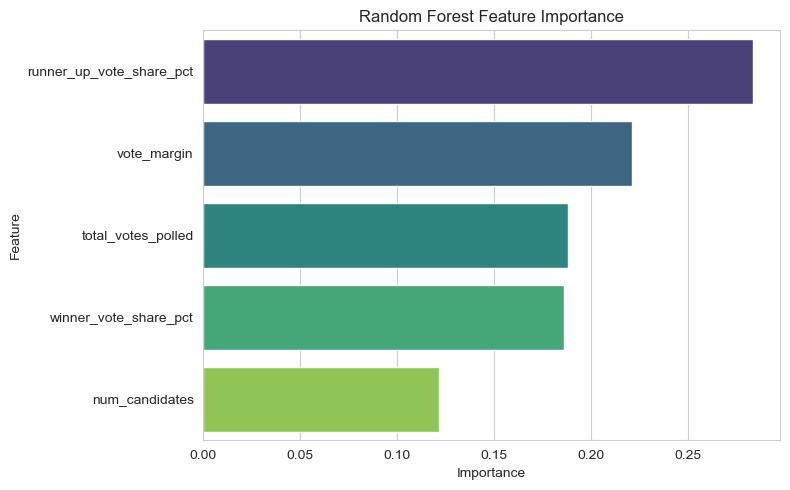

C:\Users\Admin\AppData\Local\Temp\ipykernel_18228\4087320095.py:94: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='party', y='num_constituencies', data=party_counts_pred, palette='tab10')


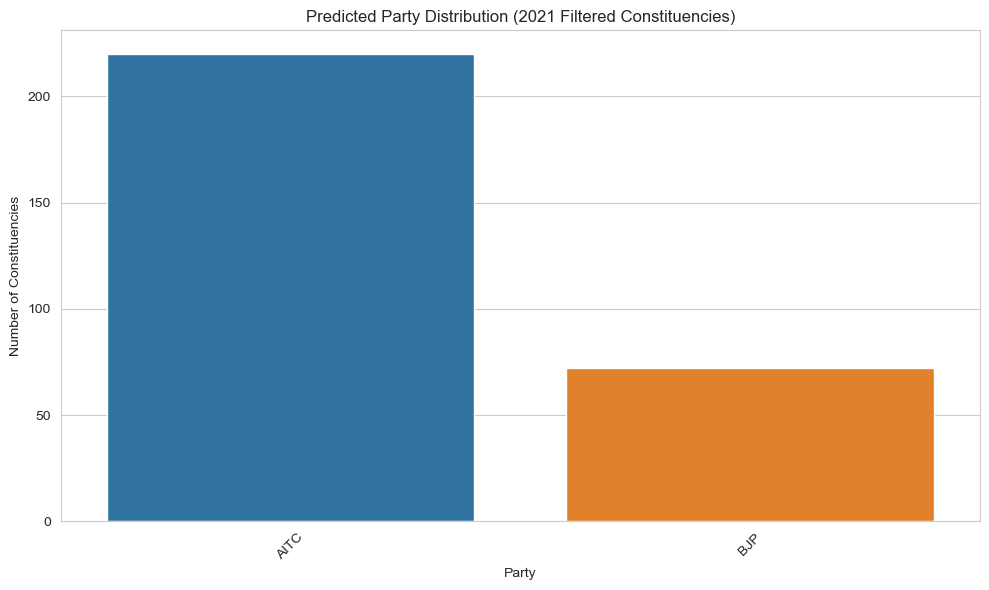

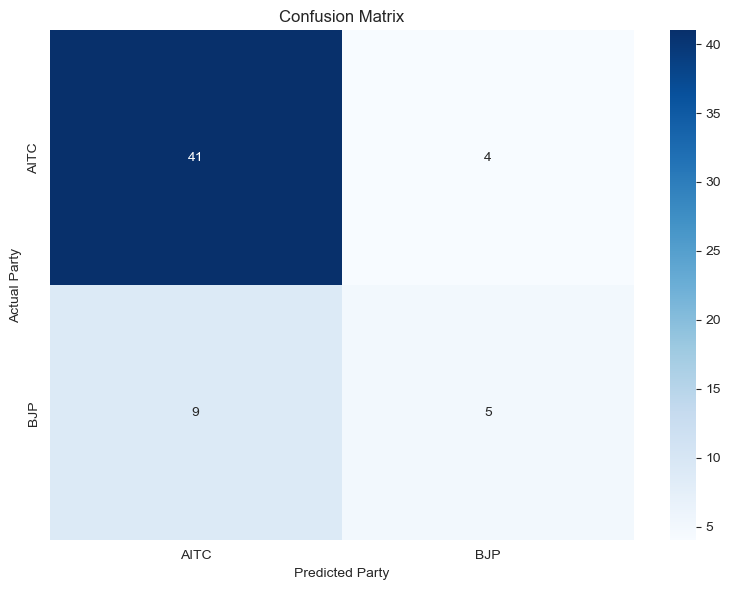

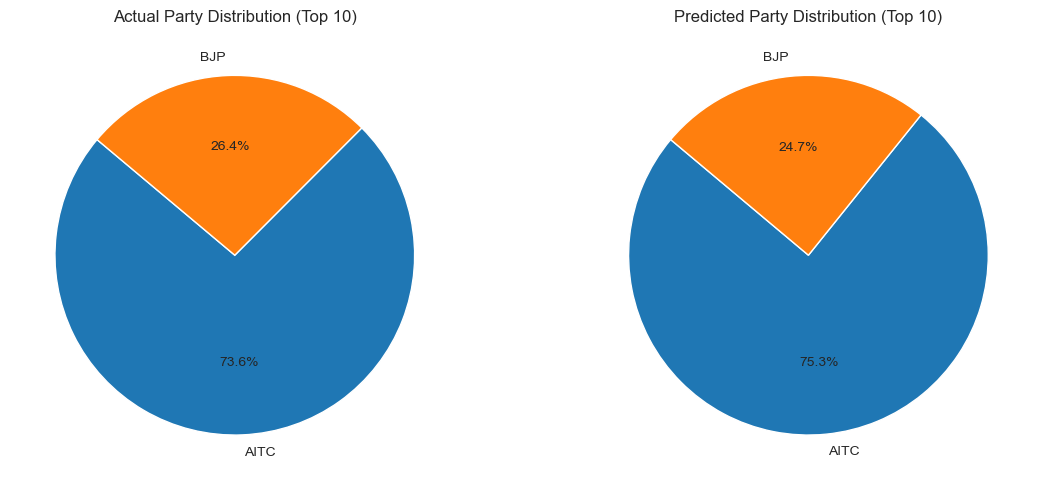

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
# Load dataset
df = pd.read_csv("constituency_results_2021.csv")


features = ['total_votes_polled', 'num_candidates', 'vote_margin', 'winner_vote_share_pct', 'runner_up_vote_share_pct']
X = df[features]


party_counts = df['winner_party'].value_counts()
df_filtered = df[df['winner_party'].isin(party_counts[party_counts>=2].index)]
X_filtered = df_filtered[features]


le_party = LabelEncoder()
y_filtered = le_party.fit_transform(df_filtered['winner_party'])


X_train, X_test, y_train, y_test = train_test_split(X_filtered, y_filtered, test_size=0.2, random_state=42)

rf = RandomForestClassifier(n_estimators=200, random_state=42)
rf.fit(X_train, y_train)


y_pred = rf.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))

labels_in_test = np.unique(y_test)
print("\nClassification Report:\n", classification_report(
    y_test,
    y_pred,
    labels=labels_in_test,
    target_names=le_party.inverse_transform(labels_in_test),
    zero_division=0
))


df_filtered['predicted_party_encoded'] = rf.predict(X_filtered)
df_filtered['predicted_party'] = le_party.inverse_transform(df_filtered['predicted_party_encoded'])


df_filtered.to_csv("constituency_predictions_2021_filtered.csv", index=False)


sns.set_style("whitegrid")

feat_importance = pd.DataFrame({
    'feature': features,
    'importance': rf.feature_importances_
}).sort_values('importance', ascending=False)

plt.figure(figsize=(8,5))
sns.barplot(x='importance', y='feature', data=feat_importance, palette='viridis')
plt.title("Random Forest Feature Importance")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.savefig("feature_importance.png")
plt.show()

party_counts_pred = df_filtered['predicted_party'].value_counts().reset_index()
party_counts_pred.columns = ['party', 'num_constituencies']

plt.figure(figsize=(10,6))
sns.barplot(x='party', y='num_constituencies', data=party_counts_pred, palette='tab10')
plt.title("Predicted Party Distribution (2021 Filtered Constituencies)")
plt.ylabel("Number of Constituencies")
plt.xlabel("Party")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("predicted_party_distribution.png")
plt.show()

cm = confusion_matrix(y_test, y_pred, labels=labels_in_test)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=le_party.inverse_transform(labels_in_test), 
            yticklabels=le_party.inverse_transform(labels_in_test), cmap='Blues')
plt.title("Confusion Matrix")
plt.xlabel("Predicted Party")
plt.ylabel("Actual Party")
plt.tight_layout()
plt.savefig("confusion_matrix.png")
plt.show()


party_counts_actual = df_filtered['winner_party'].value_counts().head(10)
party_counts_pred_top = df_filtered['predicted_party'].value_counts().head(10)

plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.pie(party_counts_actual, labels=party_counts_actual.index, autopct='%1.1f%%', startangle=140)
plt.title("Actual Party Distribution (Top 10)")

plt.subplot(1,2,2)
plt.pie(party_counts_pred_top, labels=party_counts_pred_top.index, autopct='%1.1f%%', startangle=140)
plt.title("Predicted Party Distribution (Top 10)")

plt.tight_layout()
plt.savefig("party_distribution_comparison.png")
plt.show()
